# DMET 1001 – Image Processing | Assignment 2: Semantic Segmentation
**German University in Cairo — Spring 2026**

Dataset: Oxford-IIIT Pet Dataset  
Models: A (Dice) | B (Hausdorff-inspired) | C (Tversky) | D (Combined)

## 1. Imports & Reproducibility

In [1]:
import os, random, tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image
from scipy.spatial.distance import cdist
from scipy.ndimage import distance_transform_edt, binary_erosion

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Device: cuda | PyTorch: 2.10.0+cu128


## 2. Dataset Download & Preprocessing

**Dataset:** Oxford-IIIT Pet Dataset — 37 pet breeds, ~7,400 images with trimap segmentation masks.  
**Subset:** 1000 images sampled with `seed=42`.  

**Trimap mask values:**
- 1 = foreground (pet body)
- 2 = background
- 3 = uncertain / border region

We binarise by treating label 1 as foreground and everything else as background.

**Preprocessing:**
- Resize to 256×256
- Grayscale images normalised to [0, 1]
- Masks binarised: foreground = (trimap == 1)
- Training augmentation: random horizontal flip + rotation ±15°, applied identically to image and mask

**Split (seed=42):** 70% train / 15% val / 15% test — identical across all models.

In [2]:
# images.tar.gz is corrupted / incomplete.
# Delete and re-download automatically.

import os
import urllib.request
import tarfile
from pathlib import Path

DATA_DIR = Path('./oxford_pet')
DATA_DIR.mkdir(exist_ok=True)

IMAGES_URL = 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz'
ANNOTS_URL = 'https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz'


def download_and_extract(url, dest_dir):
    fname = dest_dir / Path(url).name

    # Download if missing
    if not fname.exists():
        print(f'Downloading {fname.name} ...')
        urllib.request.urlretrieve(url, fname)

    # Try extraction
    try:
        print(f'Extracting {fname.name} ...')
        with tarfile.open(fname, 'r:gz') as tar:
            tar.extractall(dest_dir)
        print('Done.')

    except Exception as e:
        print(f'{fname.name} corrupted. Re-downloading...')

        fname.unlink()   # delete bad file

        urllib.request.urlretrieve(url, fname)

        print('Downloaded again. Extracting...')

        with tarfile.open(fname, 'r:gz') as tar:
            tar.extractall(dest_dir)

        print('Done.')


download_and_extract(IMAGES_URL, DATA_DIR)
download_and_extract(ANNOTS_URL, DATA_DIR)

IMAGES_DIR  = DATA_DIR / 'images'
TRIMAPS_DIR = DATA_DIR / 'annotations' / 'trimaps'

print(IMAGES_DIR.exists())
print(TRIMAPS_DIR.exists())

Extracting images.tar.gz ...


/tmp/ipykernel_2279/194896985.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dest_dir)


Done.
Extracting annotations.tar.gz ...
Done.
True
True


In [3]:
def collect_pairs(images_dir: Path, trimaps_dir: Path):
    """
    Match each .jpg image to its .png trimap mask.
    Only keep pairs where both files exist.
    Skip files starting with '.' (hidden files on some systems).
    """
    pairs = []
    for img_path in sorted(images_dir.glob('*.jpg')):
        if img_path.name.startswith('.'):
            continue
        mask_path = trimaps_dir / (img_path.stem + '.png')
        if mask_path.exists():
            pairs.append((img_path, mask_path))
    return pairs

all_pairs = collect_pairs(IMAGES_DIR, TRIMAPS_DIR)
print(f'Total pairs found: {len(all_pairs)}')
if len(all_pairs) == 0:
    raise RuntimeError('No image-mask pairs found. Check IMAGES_DIR and TRIMAPS_DIR.')

# Sample 1000 with fixed seed
random.seed(SEED)
if len(all_pairs) >= 1000:
    all_pairs = random.sample(all_pairs, 1000)
    print('Using 1000 sampled pairs.')
else:
    print(f'Using all {len(all_pairs)} available pairs.')

# Fixed 70/15/15 split — identical for all models
random.seed(SEED)
shuffled = all_pairs.copy()
random.shuffle(shuffled)
n        = len(shuffled)
n_train  = int(0.70 * n)
n_val    = int(0.15 * n)
train_pairs = shuffled[:n_train]
val_pairs   = shuffled[n_train:n_train + n_val]
test_pairs  = shuffled[n_train + n_val:]
print(f'Split → Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

Total pairs found: 7390
Using 1000 sampled pairs.
Split → Train: 700 | Val: 150 | Test: 150


In [4]:
IMG_SIZE = 256

class OxfordPetDataset(Dataset):
    """
    Oxford-IIIT Pet Dataset loader.
    Images are loaded as grayscale.
    Trimap masks are binarised: foreground = (pixel value == 1).
    """
    def __init__(self, pairs, augment=False):
        self.pairs   = pairs
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img  = Image.open(img_path).convert('L')   # grayscale
        mask = Image.open(mask_path)               # keep as-is (values 1,2,3)

        img  = TF.resize(img,  [IMG_SIZE, IMG_SIZE])
        mask = TF.resize(mask, [IMG_SIZE, IMG_SIZE], interpolation=Image.NEAREST)

        if self.augment:
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)
            angle = random.uniform(-15, 15)
            img   = TF.rotate(img,  angle)
            mask  = TF.rotate(mask, angle)

        img       = TF.to_tensor(img)                          # [1, H, W] float [0,1]
        mask_np   = np.array(mask, dtype=np.uint8)             # H x W, values {1,2,3}
        binary    = torch.from_numpy((mask_np == 1).astype(np.float32))  # 1=pet, else 0
        binary    = binary.unsqueeze(0)                        # [1, H, W]

        return img, binary


train_ds = OxfordPetDataset(train_pairs, augment=True)
val_ds   = OxfordPetDataset(val_pairs,   augment=False)
test_ds  = OxfordPetDataset(test_pairs,  augment=False)

# Quick check
_img, _mask = train_ds[0]
print(f'Image shape: {_img.shape} | Mask shape: {_mask.shape}')
print(f'Mask unique values: {_mask.unique().tolist()}')

PIN   = torch.cuda.is_available()
BATCH = 8
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=PIN)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=PIN)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=PIN)
print('DataLoaders ready.')

Image shape: torch.Size([1, 256, 256]) | Mask shape: torch.Size([1, 256, 256])
Mask unique values: [0.0, 1.0]
DataLoaders ready.


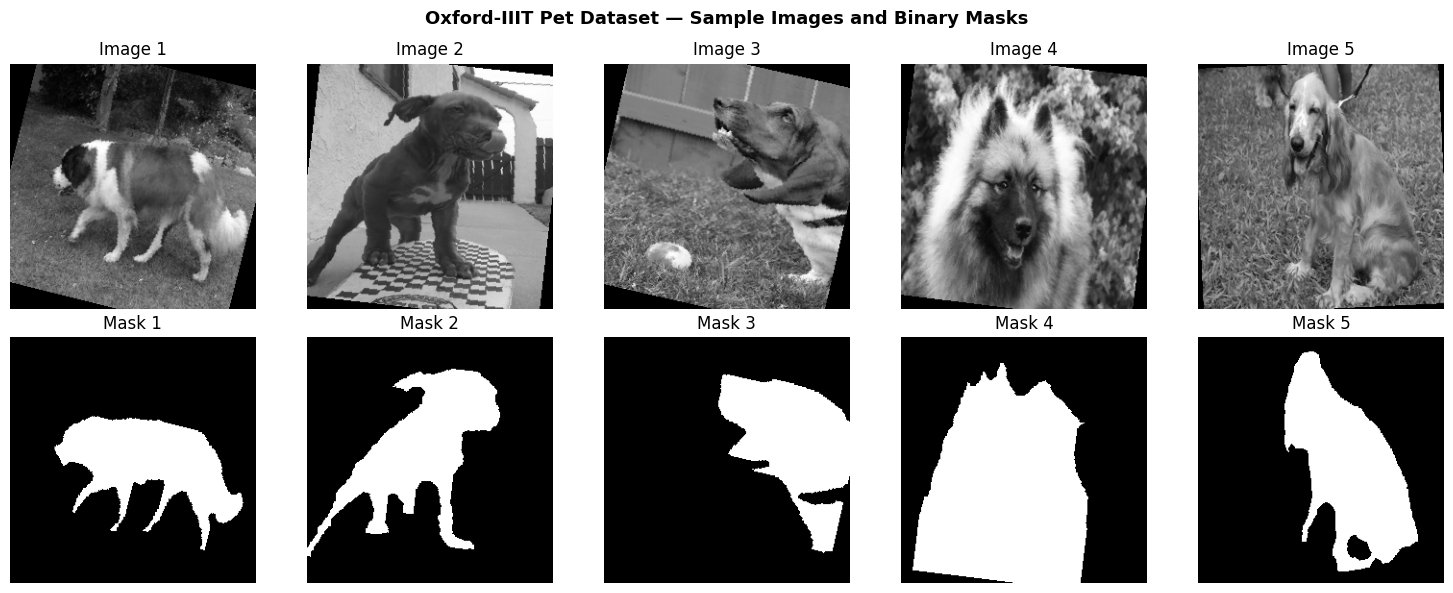

Saved: fig0_sample_data.png


In [5]:
# Visualise 5 sample image/mask pairs
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Oxford-IIIT Pet Dataset — Sample Images and Binary Masks', fontsize=13, fontweight='bold')
for i in range(5):
    img, mask = train_ds[i]
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f'Image {i+1}'); axes[0, i].axis('off')
    axes[1, i].imshow(mask.squeeze(), cmap='gray')
    axes[1, i].set_title(f'Mask {i+1}');  axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('fig0_sample_data.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: fig0_sample_data.png')

## 3. U-Net Architecture

Small U-Net with encoder feature depth [32, 64, 128, 256], transposed-convolution upsampling, skip connections, and a 1×1 Conv + Sigmoid output for binary segmentation.

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=1, features=[32, 64, 128, 256]):
        super().__init__()
        f = features
        self.enc1 = DoubleConv(in_ch, f[0])
        self.enc2 = DoubleConv(f[0],  f[1])
        self.enc3 = DoubleConv(f[1],  f[2])
        self.enc4 = DoubleConv(f[2],  f[3])
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(f[3], f[3]*2)
        self.up4  = nn.ConvTranspose2d(f[3]*2, f[3], 2, stride=2)
        self.up3  = nn.ConvTranspose2d(f[3],   f[2], 2, stride=2)
        self.up2  = nn.ConvTranspose2d(f[2],   f[1], 2, stride=2)
        self.up1  = nn.ConvTranspose2d(f[1],   f[0], 2, stride=2)
        self.dec4 = DoubleConv(f[3]*2, f[3])
        self.dec3 = DoubleConv(f[2]*2, f[2])
        self.dec2 = DoubleConv(f[1]*2, f[1])
        self.dec1 = DoubleConv(f[0]*2, f[0])
        self.out  = nn.Conv2d(f[0], 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return torch.sigmoid(self.out(d1))


_m = UNet().to(DEVICE)
_x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
assert _m(_x).shape == (2, 1, IMG_SIZE, IMG_SIZE)
print(f'UNet OK | params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _x

UNet OK | params: 7,762,465


In [7]:
EPS = 1e-6

# ── Model A: Dice Loss ────────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def forward(self, pred, target):
        p, t = pred.view(-1), target.view(-1)
        return 1.0 - (2.0 * (p * t).sum() + EPS) / (p.sum() + t.sum() + EPS)


# ── Model B: Hausdorff-inspired Loss ─────────────────────────────────────────
def compute_distance_maps(mask_np):
    """Normalised (dt_fg, dt_bg) distance transforms for a binary mask [H,W]."""
    fg    = mask_np.astype(bool)
    dt_fg = distance_transform_edt(fg)
    dt_bg = distance_transform_edt(~fg)
    dt_fg = (dt_fg / (dt_fg.max() + EPS)).astype(np.float32)
    dt_bg = (dt_bg / (dt_bg.max() + EPS)).astype(np.float32)
    return dt_fg, dt_bg


class HausdorffLoss(nn.Module):
    """
    Differentiable Hausdorff-inspired loss (assignment specification):
        pos_term = dt_fg * softplus(-y_pred)
        neg_term = dt_bg * softplus( y_pred)
        loss = mean(pos_term + neg_term)
    The sigmoid output is converted to logit space before softplus.
    """
    def forward(self, pred, target):
        logit = torch.logit(pred.clamp(EPS, 1.0 - EPS))
        B, loss = target.shape[0], 0.0
        for i in range(B):
            dt_fg, dt_bg = compute_distance_maps(target[i, 0].cpu().numpy())
            dt_fg_t = torch.from_numpy(dt_fg).unsqueeze(0).to(pred.device)
            dt_bg_t = torch.from_numpy(dt_bg).unsqueeze(0).to(pred.device)
            loss += (dt_fg_t * F.softplus(-logit[i]) +
                     dt_bg_t * F.softplus( logit[i])).mean()
        return loss / B


# ── Model C: Tversky Loss ─────────────────────────────────────────────────────
class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7):
        super().__init__()
        self.alpha, self.beta = alpha, beta
    def forward(self, pred, target):
        p, t = pred.view(-1), target.view(-1)
        TP   = (p * t).sum()
        FP   = (p * (1 - t)).sum()
        FN   = ((1 - p) * t).sum()
        return 1.0 - (TP + EPS) / (TP + self.alpha * FP + self.beta * FN + EPS)


# ── Model D: Combined Loss ────────────────────────────────────────────────────
class CombinedLoss(nn.Module):
    def __init__(self, loss1, loss2, alpha=0.5, beta=0.5):
        super().__init__()
        self.loss1 = loss1
        self.loss2 = loss2
        self.alpha = alpha
        self.beta  = beta
    def forward(self, pred, target):
        return self.alpha * self.loss1(pred, target) + self.beta * self.loss2(pred, target)

print('Loss functions: DiceLoss | HausdorffLoss | TverskyLoss | CombinedLoss')

Loss functions: DiceLoss | HausdorffLoss | TverskyLoss | CombinedLoss


## 5. Evaluation Metrics: Dice Score, IoU, HD95

In [8]:
# Assignment-provided HD95 function
def hd95(pred_points, gt_points):
    D  = cdist(pred_points, gt_points)
    d1 = np.min(D, axis=1)
    d2 = np.min(D, axis=0)
    return max(np.percentile(d1, 95), np.percentile(d2, 95))


def boundary_points(mask_np):
    eroded   = binary_erosion(mask_np.astype(bool))
    boundary = mask_np.astype(bool) & ~eroded
    return np.column_stack(np.where(boundary))


def dice_score(pred_bin, target):
    p, t = pred_bin.view(-1).float(), target.view(-1).float()
    return ((2 * (p*t).sum() + EPS) / (p.sum() + t.sum() + EPS)).item()


def iou_score(pred_bin, target):
    p, t  = pred_bin.view(-1).float(), target.view(-1).float()
    inter = (p * t).sum()
    return ((inter + EPS) / (p.sum() + t.sum() - inter + EPS)).item()


def hd95_batch(pred_bin, target):
    scores = []
    for i in range(pred_bin.shape[0]):
        p_pts = boundary_points(pred_bin[i, 0].cpu().numpy())
        g_pts = boundary_points(target[i, 0].cpu().numpy())
        if len(p_pts) > 0 and len(g_pts) > 0:
            scores.append(hd95(p_pts, g_pts))
    return np.mean(scores) if scores else np.nan


@torch.no_grad()
def evaluate(model, loader, threshold=0.5):
    model.eval()
    dice_l, iou_l, hd_l = [], [], []
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds_bin   = (model(imgs) > threshold).float()
        dice_l.append(dice_score(preds_bin, masks))
        iou_l.append(iou_score(preds_bin,   masks))
        h = hd95_batch(preds_bin, masks)
        if not np.isnan(h):
            hd_l.append(h)
    return {
        'dice': np.mean(dice_l),
        'iou':  np.mean(iou_l),
        'hd95': np.mean(hd_l) if hd_l else np.nan
    }


print('Metrics defined: Dice Score | IoU | HD95')

Metrics defined: Dice Score | IoU | HD95


## 6. Training Loop

In [9]:
def train_model(name, loss_fn, lr=1e-3, epochs=60, patience=12, weight_decay=1e-4):
    print(f'\n{"="*60}\nTraining {name}\n{"="*60}')
    torch.manual_seed(SEED)
    model     = UNet(in_ch=1).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    hist = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': [], 'val_hd95': []}
    best_val, best_w, no_imp = float('inf'), None, 0

    for ep in range(1, epochs + 1):
        # Train
        model.train()
        t_losses = []
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(imgs), masks)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_losses.append(loss.item())
        scheduler.step()

        # Validate
        model.eval()
        v_losses = []
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                v_losses.append(loss_fn(model(imgs), masks).item())

        vm = evaluate(model, val_loader)
        tl = np.mean(t_losses)
        vl = np.mean(v_losses)
        hist['train_loss'].append(tl)
        hist['val_loss'].append(vl)
        hist['val_dice'].append(vm['dice'])
        hist['val_iou'].append(vm['iou'])
        hist['val_hd95'].append(vm['hd95'])

        if ep % 5 == 0 or ep == 1:
            print(f'  Ep {ep:3d}/{epochs} | TL {tl:.4f} | VL {vl:.4f} | '
                  f'Dice {vm["dice"]:.4f} | IoU {vm["iou"]:.4f} | HD95 {vm["hd95"]:.2f}')

        # Early stopping
        if vl < best_val:
            best_val = vl
            best_w   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp   = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f'  Early stop at epoch {ep}.')
                break

    model.load_state_dict(best_w)
    torch.save(best_w, f'{name}_weights.pth')
    print(f'  Saved: {name}_weights.pth | best val loss: {best_val:.4f}')
    return model, hist


print('Training function ready.')

Training function ready.


## 7. Train All Four Models

In [10]:
# Model A — Dice Loss
model_A, hist_A = train_model('ModelA_Dice', DiceLoss(), lr=1e-3, epochs=60, patience=12)


Training ModelA_Dice
  Ep   1/60 | TL 0.4775 | VL 0.4219 | Dice 0.6179 | IoU 0.4496 | HD95 66.63
  Ep   5/60 | TL 0.3791 | VL 0.4010 | Dice 0.6263 | IoU 0.4584 | HD95 66.29
  Ep  10/60 | TL 0.3209 | VL 0.3513 | Dice 0.6503 | IoU 0.4846 | HD95 56.40
  Ep  15/60 | TL 0.3054 | VL 0.6290 | Dice 0.3732 | IoU 0.2310 | HD95 70.71
  Ep  20/60 | TL 0.2658 | VL 0.3087 | Dice 0.6922 | IoU 0.5319 | HD95 57.53
  Ep  25/60 | TL 0.2476 | VL 0.2739 | Dice 0.7265 | IoU 0.5728 | HD95 60.87
  Ep  30/60 | TL 0.2221 | VL 0.2051 | Dice 0.7956 | IoU 0.6621 | HD95 49.70
  Ep  35/60 | TL 0.2161 | VL 0.1972 | Dice 0.8037 | IoU 0.6733 | HD95 48.22
  Ep  40/60 | TL 0.1888 | VL 0.1864 | Dice 0.8142 | IoU 0.6883 | HD95 49.83
  Ep  45/60 | TL 0.1700 | VL 0.1719 | Dice 0.8287 | IoU 0.7089 | HD95 43.18
  Ep  50/60 | TL 0.1597 | VL 0.1652 | Dice 0.8354 | IoU 0.7190 | HD95 47.21
  Ep  55/60 | TL 0.1500 | VL 0.1540 | Dice 0.8466 | IoU 0.7354 | HD95 44.16
  Ep  60/60 | TL 0.1461 | VL 0.1584 | Dice 0.8423 | IoU 0.7291 | H

In [11]:
# Model B — Hausdorff-inspired Loss
# Lower LR: distance-map-weighted gradients tend to be larger in early epochs
model_B, hist_B = train_model('ModelB_Hausdorff', HausdorffLoss(), lr=5e-4, epochs=60, patience=12)


Training ModelB_Hausdorff
  Ep   1/60 | TL 0.1683 | VL 0.1525 | Dice 0.6390 | IoU 0.4715 | HD95 60.81
  Ep   5/60 | TL 0.0937 | VL 0.1097 | Dice 0.6935 | IoU 0.5322 | HD95 54.36
  Ep  10/60 | TL 0.0767 | VL 0.0892 | Dice 0.6959 | IoU 0.5356 | HD95 56.89
  Ep  15/60 | TL 0.0678 | VL 0.1006 | Dice 0.6708 | IoU 0.5060 | HD95 58.04
  Ep  20/60 | TL 0.0643 | VL 0.0628 | Dice 0.7643 | IoU 0.6201 | HD95 50.27
  Ep  25/60 | TL 0.0577 | VL 0.0964 | Dice 0.7405 | IoU 0.5895 | HD95 58.09
  Ep  30/60 | TL 0.0534 | VL 0.0556 | Dice 0.7925 | IoU 0.6575 | HD95 47.03
  Ep  35/60 | TL 0.0481 | VL 0.0525 | Dice 0.7987 | IoU 0.6663 | HD95 45.34
  Ep  40/60 | TL 0.0430 | VL 0.0451 | Dice 0.8240 | IoU 0.7015 | HD95 44.96
  Ep  45/60 | TL 0.0364 | VL 0.0470 | Dice 0.8214 | IoU 0.6979 | HD95 42.58
  Ep  50/60 | TL 0.0307 | VL 0.0468 | Dice 0.8265 | IoU 0.7055 | HD95 44.24
  Ep  55/60 | TL 0.0272 | VL 0.0445 | Dice 0.8310 | IoU 0.7121 | HD95 43.73
  Ep  60/60 | TL 0.0270 | VL 0.0456 | Dice 0.8314 | IoU 0.712

In [12]:
# Model C — Tversky Loss (alpha=0.3, beta=0.7)
model_C, hist_C = train_model('ModelC_Tversky', TverskyLoss(0.3, 0.7), lr=1e-3, epochs=60, patience=12)


Training ModelC_Tversky
  Ep   1/60 | TL 0.4022 | VL 0.3711 | Dice 0.5924 | IoU 0.4229 | HD95 71.83
  Ep   5/60 | TL 0.3186 | VL 0.3018 | Dice 0.6096 | IoU 0.4413 | HD95 73.36
  Ep  10/60 | TL 0.2797 | VL 0.2745 | Dice 0.6375 | IoU 0.4702 | HD95 67.56
  Ep  15/60 | TL 0.2546 | VL 0.4447 | Dice 0.6105 | IoU 0.4422 | HD95 68.92
  Ep  20/60 | TL 0.2233 | VL 0.2231 | Dice 0.7611 | IoU 0.6160 | HD95 51.78
  Ep  25/60 | TL 0.2088 | VL 0.2173 | Dice 0.7126 | IoU 0.5556 | HD95 65.95
  Ep  30/60 | TL 0.1929 | VL 0.1870 | Dice 0.7449 | IoU 0.5950 | HD95 58.58
  Ep  35/60 | TL 0.1778 | VL 0.1667 | Dice 0.8012 | IoU 0.6698 | HD95 53.37
  Ep  40/60 | TL 0.1588 | VL 0.1502 | Dice 0.8080 | IoU 0.6790 | HD95 51.31
  Ep  45/60 | TL 0.1463 | VL 0.1497 | Dice 0.8392 | IoU 0.7240 | HD95 42.65
  Ep  50/60 | TL 0.1345 | VL 0.1369 | Dice 0.8331 | IoU 0.7152 | HD95 45.92
  Ep  55/60 | TL 0.1262 | VL 0.1324 | Dice 0.8395 | IoU 0.7244 | HD95 46.34
  Ep  60/60 | TL 0.1244 | VL 0.1357 | Dice 0.8449 | IoU 0.7326 

In [13]:
# ── Select best two losses from A, B, C based on validation Dice ─────────────
val_results = {}
for name, model in [
    ('A_Dice',      model_A),
    ('B_Hausdorff', model_B),
    ('C_Tversky',   model_C)
]:
    val_results[name] = evaluate(model, val_loader)
    print(f'{name:<14} | '
          f'Val Dice: {val_results[name]["dice"]:.4f} | '
          f'IoU:      {val_results[name]["iou"]:.4f} | '
          f'HD95:     {val_results[name]["hd95"]:.2f}')

# Rank by Dice
ranked = sorted(val_results.items(), key=lambda x: x[1]['dice'], reverse=True)
top1, top2 = ranked[0][0], ranked[1][0]

d1 = val_results[top1]['dice']
d2 = val_results[top2]['dice']
alpha = round(d1 / (d1 + d2), 2)
beta  = round(1.0 - alpha, 2)

# ── Determine LR: use 5e-4 if Hausdorff is in the mix, else 1e-3 ─────────────
lr_D = 5e-4 if 'B_Hausdorff' in (top1, top2) else 1e-3

print(f'\n{"="*50}')
print(f'MODEL D CONFIGURATION')
print(f'{"="*50}')
print(f'Loss 1 (L1): {top1}  |  Val Dice = {d1:.4f}  |  α = {alpha}')
print(f'Loss 2 (L2): {top2}  |  Val Dice = {d2:.4f}  |  β = {beta}')
print(f'Formula: L_combined = {alpha} * {top1} + {beta} * {top2}')
print(f'LR: {lr_D}')
print(f'{"="*50}\n')

# ── Map name → loss function ──────────────────────────────────────────────────
loss_map = {
    'A_Dice':      DiceLoss(),
    'B_Hausdorff': HausdorffLoss(),
    'C_Tversky':   TverskyLoss(0.3, 0.7),
}
loss1_fn = loss_map[top1]
loss2_fn = loss_map[top2]

# ── Train Model D ─────────────────────────────────────────────────────────────
combined_loss = CombinedLoss(loss1_fn, loss2_fn, alpha=alpha, beta=beta)
model_D, hist_D = train_model(
    'ModelD_Combined',
    combined_loss,
    lr=lr_D,
    epochs=60,
    patience=12,
)

A_Dice         | Val Dice: 0.8466 | IoU:      0.7354 | HD95:     44.16
B_Hausdorff    | Val Dice: 0.8334 | IoU:      0.7156 | HD95:     43.02
C_Tversky      | Val Dice: 0.8397 | IoU:      0.7248 | HD95:     47.05

MODEL D CONFIGURATION
Loss 1 (L1): A_Dice  |  Val Dice = 0.8466  |  α = 0.5
Loss 2 (L2): C_Tversky  |  Val Dice = 0.8397  |  β = 0.5
Formula: L_combined = 0.5 * A_Dice + 0.5 * C_Tversky
LR: 0.001


Training ModelD_Combined
  Ep   1/60 | TL 0.4335 | VL 0.4107 | Dice 0.5520 | IoU 0.3845 | HD95 86.59
  Ep   5/60 | TL 0.3349 | VL 0.3149 | Dice 0.6626 | IoU 0.4979 | HD95 62.07
  Ep  10/60 | TL 0.2975 | VL 0.3391 | Dice 0.6506 | IoU 0.4840 | HD95 62.20
  Ep  15/60 | TL 0.2631 | VL 0.2982 | Dice 0.7135 | IoU 0.5572 | HD95 51.97
  Ep  20/60 | TL 0.2442 | VL 0.2569 | Dice 0.7328 | IoU 0.5803 | HD95 55.11
  Ep  25/60 | TL 0.2241 | VL 0.2362 | Dice 0.7280 | IoU 0.5741 | HD95 61.48
  Ep  30/60 | TL 0.2063 | VL 0.2062 | Dice 0.7685 | IoU 0.6254 | HD95 53.12
  Ep  35/60 | TL 0.1916 | VL 0.

## 8. Test Set Evaluation

In [14]:
models = {
    'Model A (Dice)':      model_A,
    'Model B (Hausdorff)': model_B,
    'Model C (Tversky)':   model_C,
    'Model D (Combined)':  model_D,
}

test_results = {}
print(f'\n{"="*60}')
print(f'{"Model":<24} {"Dice":>8} {"IoU":>8} {"HD95":>10}')
print('='*60)
for name, m in models.items():
    r = evaluate(m, test_loader)
    test_results[name] = r
    print(f'{name:<24} {r["dice"]:>8.4f} {r["iou"]:>8.4f} {r["hd95"]:>10.2f}')
print('='*60)

best_dice = max(test_results, key=lambda k: test_results[k]['dice'])
best_iou  = max(test_results, key=lambda k: test_results[k]['iou'])
best_hd95 = min(test_results, key=lambda k: (
    test_results[k]['hd95'] if not np.isnan(test_results[k]['hd95']) else np.inf))
print(f'\nBest Dice:  {best_dice}')
print(f'Best IoU:   {best_iou}')
print(f'Best HD95:  {best_hd95}')


Model                        Dice      IoU       HD95
Model A (Dice)             0.8531   0.7455      40.22
Model B (Hausdorff)        0.8484   0.7388      38.94
Model C (Tversky)          0.8327   0.7155      48.37
Model D (Combined)         0.8452   0.7340      44.31

Best Dice:  Model A (Dice)
Best IoU:   Model A (Dice)
Best HD95:  Model B (Hausdorff)


## 9. Report Figures

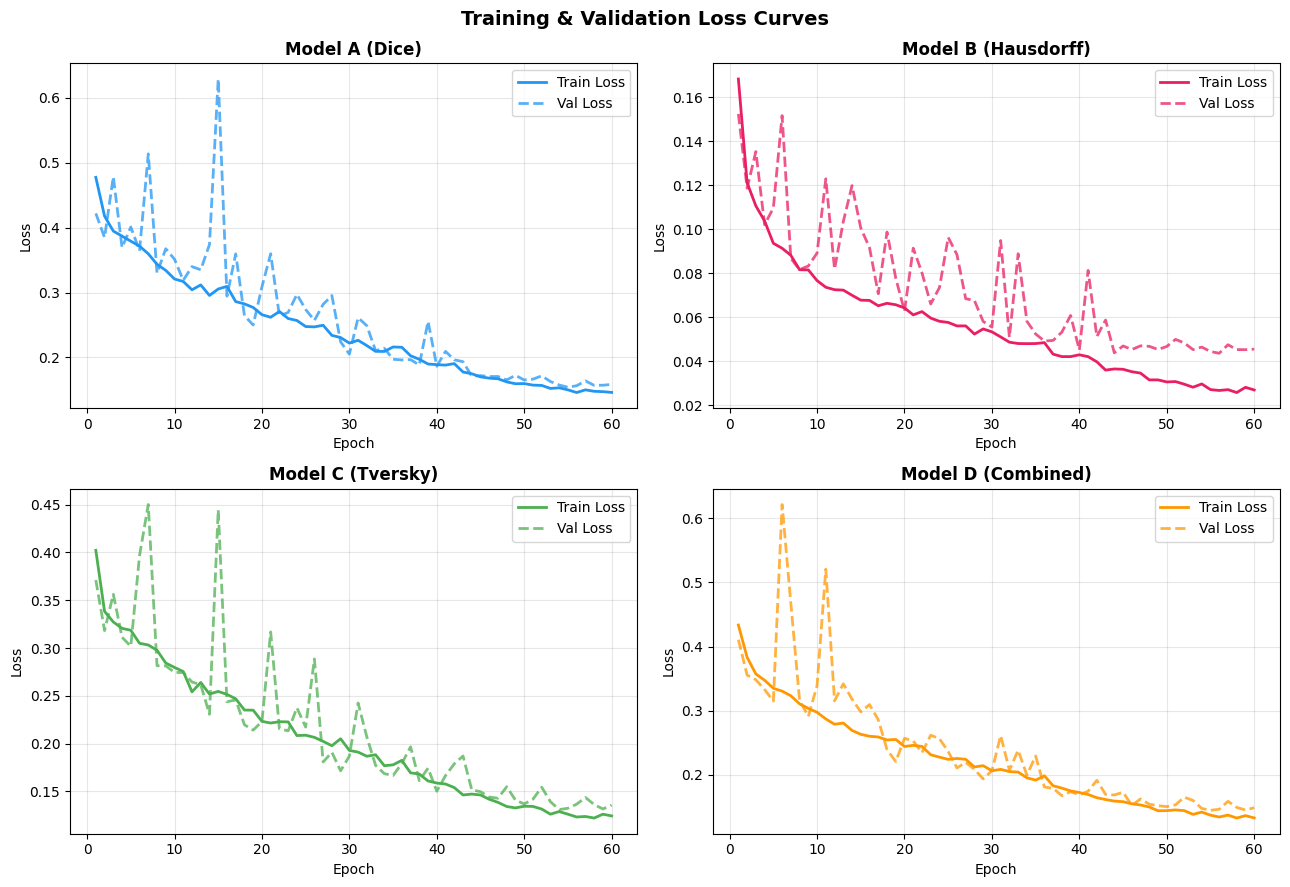

Saved: fig1_loss_curves.png


In [15]:
# ── Figure 1: Training & Validation Loss Curves ───────────────────────────────
histories = [
    ('Model A (Dice)',      hist_A, '#2196F3'),
    ('Model B (Hausdorff)', hist_B, '#E91E63'),
    ('Model C (Tversky)',   hist_C, '#4CAF50'),
    ('Model D (Combined)',  hist_D, '#FF9800'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Training & Validation Loss Curves', fontsize=14, fontweight='bold')
for ax, (name, hist, color) in zip(axes.flat, histories):
    ep = range(1, len(hist['train_loss']) + 1)
    ax.plot(ep, hist['train_loss'], color=color, lw=2, label='Train Loss')
    ax.plot(ep, hist['val_loss'],   color=color, lw=2, ls='--', alpha=0.75, label='Val Loss')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_loss_curves.png')

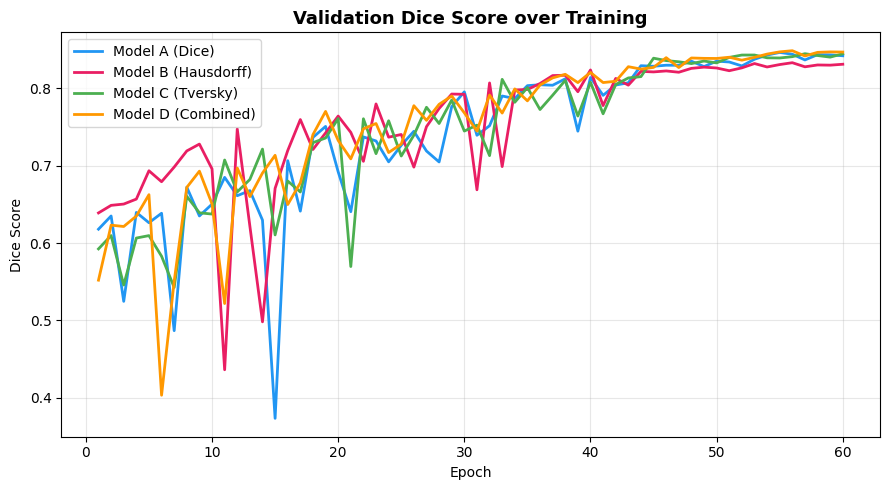

Saved: fig2_dice_curves.png


In [16]:
# ── Figure 2: Validation Dice Curves ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('Validation Dice Score over Training', fontsize=13, fontweight='bold')
for name, hist, color in histories:
    ax.plot(range(1, len(hist['val_dice']) + 1), hist['val_dice'],
            label=name, color=color, lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Dice Score')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_dice_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_dice_curves.png')

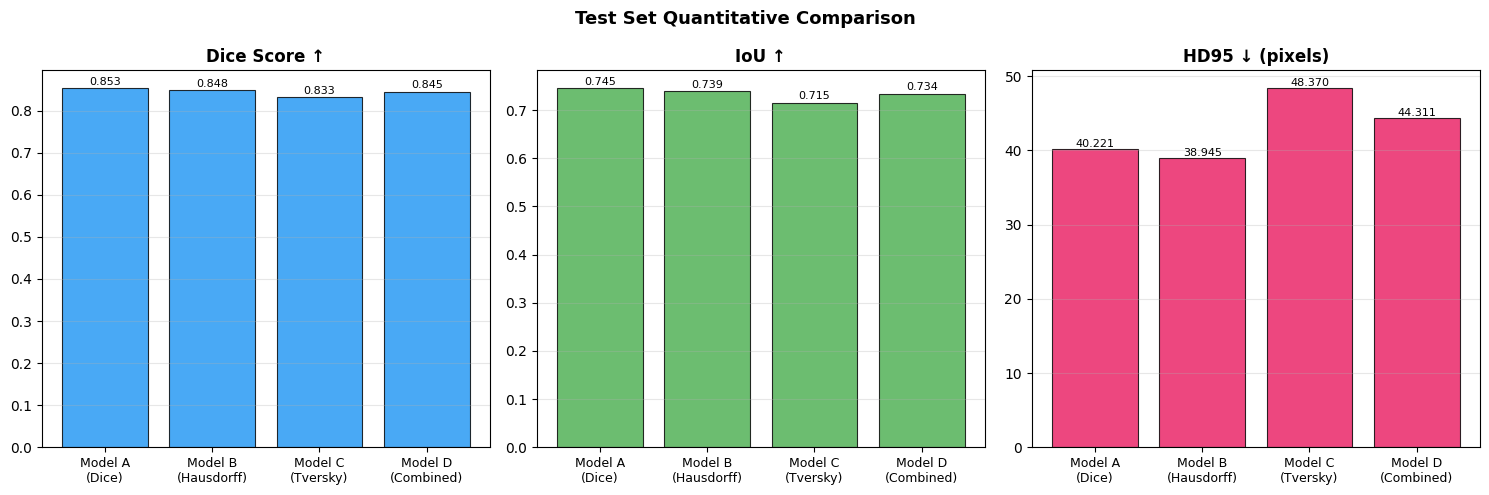

Saved: fig3_quantitative.png


In [17]:
# ── Figure 3: Quantitative Comparison Bar Charts ──────────────────────────────
names = list(test_results.keys())
x     = np.arange(len(names))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Test Set Quantitative Comparison', fontsize=13, fontweight='bold')
for ax, metric, title, c in zip(
    axes,
    ['dice',    'iou',  'hd95'],
    ['Dice Score ↑', 'IoU ↑', 'HD95 ↓ (pixels)'],
    ['#2196F3', '#4CAF50', '#E91E63']
):
    vals = [test_results[n][metric] for n in names]
    bars = ax.bar(x, vals, color=c, alpha=0.82, edgecolor='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' (', '\n(') for n in names], fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('fig3_quantitative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_quantitative.png')

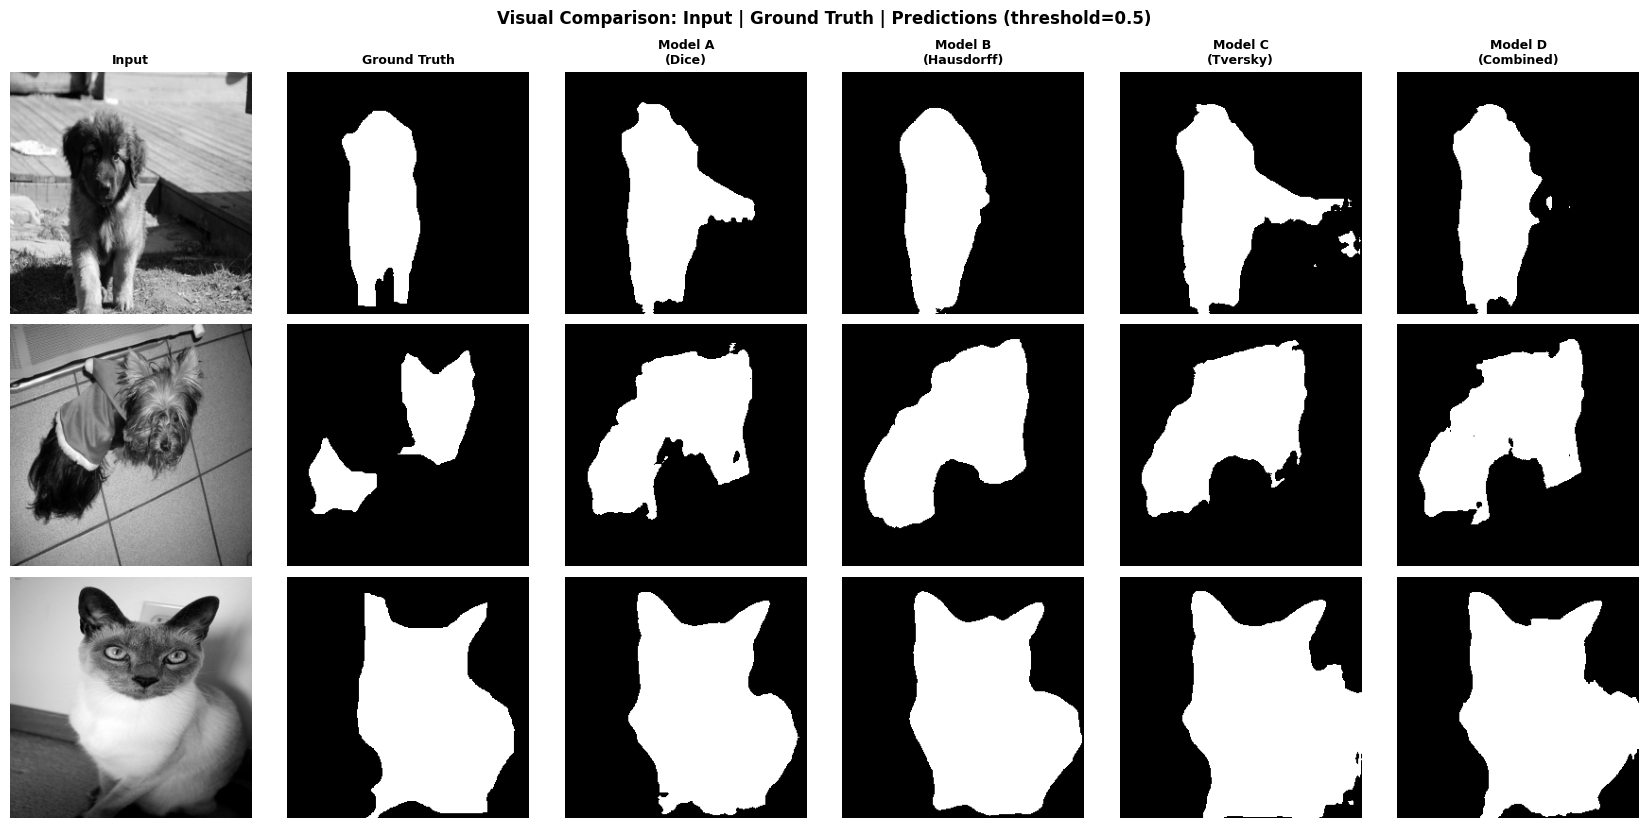

Saved: fig4_visual_comparison.png


In [18]:
# ── Figure 4: Visual Comparison — 3 test samples × all 4 models ──────────────
SAMPLE_IDX = [0, 5, 10]

@torch.no_grad()
def predict_sample(model, dataset, idx):
    model.eval()
    img, mask = dataset[idx]
    pred = model(img.unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()
    return img.squeeze().numpy(), mask.squeeze().numpy(), pred


n_rows     = len(SAMPLE_IDX)
col_titles = ['Input', 'Ground Truth',
              'Model A\n(Dice)', 'Model B\n(Hausdorff)',
              'Model C\n(Tversky)', 'Model D\n(Combined)']
n_cols = len(col_titles)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.8, n_rows * 2.8))
fig.suptitle('Visual Comparison: Input | Ground Truth | Predictions (threshold=0.5)',
             fontsize=12, fontweight='bold')

for r, s_idx in enumerate(SAMPLE_IDX):
    img_np, gt_np, _ = predict_sample(model_A, test_ds, s_idx)
    preds = [predict_sample(m, test_ds, s_idx)[2] for m in models.values()]
    axes[r, 0].imshow(img_np, cmap='gray'); axes[r, 0].axis('off')
    axes[r, 1].imshow(gt_np,  cmap='gray'); axes[r, 1].axis('off')
    for c, pred in enumerate(preds, start=2):
        axes[r, c].imshow((pred > 0.5).astype(float), cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(f'Sample {r+1}', fontsize=10)

for c, title in enumerate(col_titles):
    axes[0, c].set_title(title, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_visual_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_visual_comparison.png')

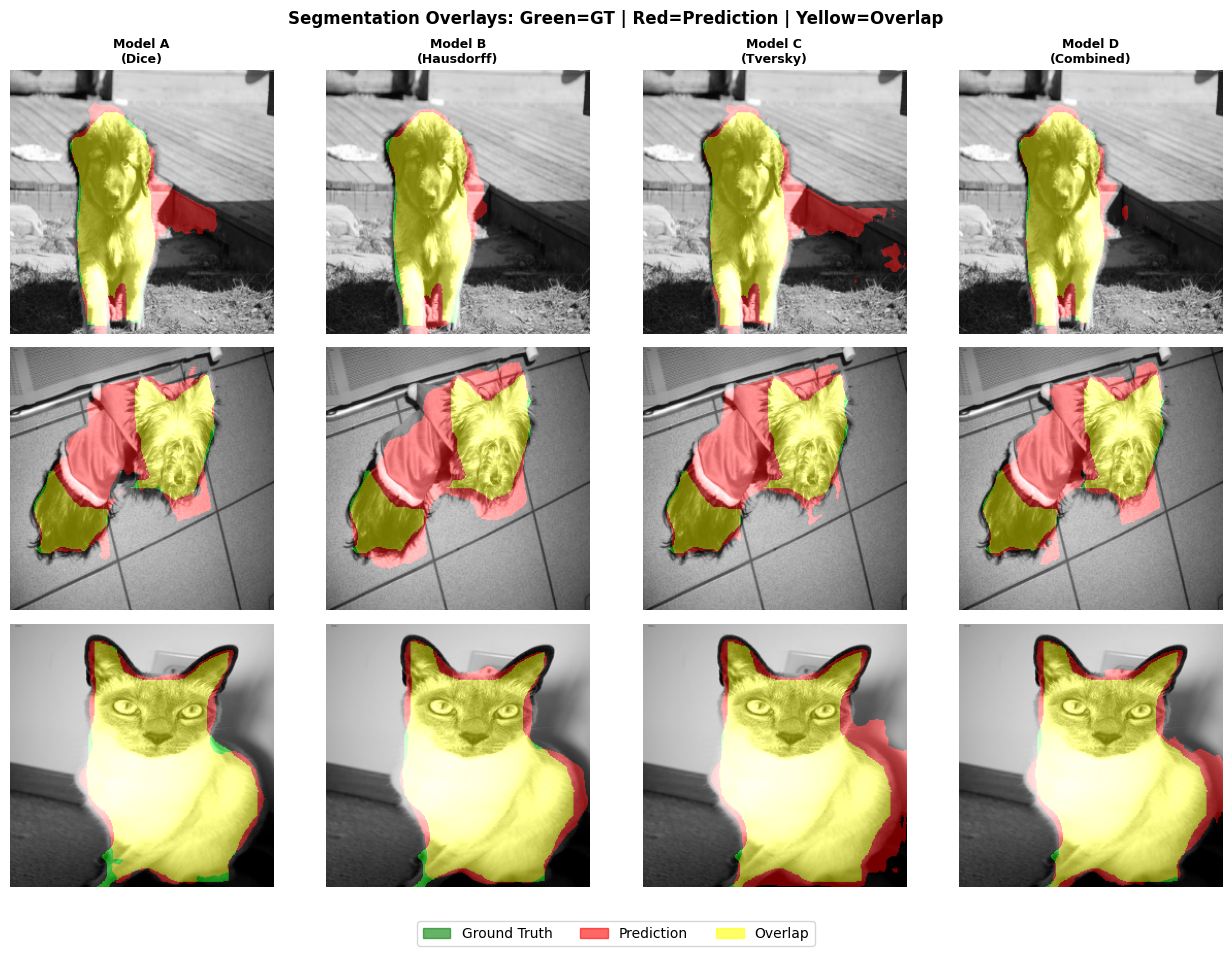

Saved: fig5_overlay.png


In [19]:
# ── Figure 5: Overlay — GT vs Prediction ─────────────────────────────────────
# Green = GT | Red = Prediction | Yellow = Overlap
fig, axes = plt.subplots(n_rows, len(models), figsize=(len(models) * 3.2, n_rows * 3.2))
fig.suptitle('Segmentation Overlays: Green=GT | Red=Prediction | Yellow=Overlap',
             fontsize=12, fontweight='bold')

for c, (mname, m) in enumerate(models.items()):
    for r, s_idx in enumerate(SAMPLE_IDX):
        img_np, gt_np, pred_np = predict_sample(m, test_ds, s_idx)
        pred_bin = (pred_np > 0.5).astype(float)
        overlay  = np.stack([img_np, img_np, img_np], axis=-1)
        overlay[:, :, 1] = np.clip(overlay[:, :, 1] + gt_np    * 0.45, 0, 1)
        overlay[:, :, 0] = np.clip(overlay[:, :, 0] + pred_bin * 0.45, 0, 1)
        axes[r, c].imshow(overlay); axes[r, c].axis('off')
        if r == 0:
            axes[r, c].set_title(mname.replace(' (', '\n('), fontsize=9, fontweight='bold')
        if c == 0:
            axes[r, c].set_ylabel(f'Sample {r+1}', fontsize=9)

handles = [
    mpatches.Patch(color='green',  alpha=0.6, label='Ground Truth'),
    mpatches.Patch(color='red',    alpha=0.6, label='Prediction'),
    mpatches.Patch(color='yellow', alpha=0.6, label='Overlap'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('fig5_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_overlay.png')

In [20]:
# ── File Checklist ────────────────────────────────────────────────────────────
files = [
    'ModelA_Dice_weights.pth',
    'ModelB_Hausdorff_weights.pth',
    'ModelC_Tversky_weights.pth',
    'ModelD_Combined_weights.pth',
    'fig0_sample_data.png',
    'fig1_loss_curves.png',
    'fig2_dice_curves.png',
    'fig3_quantitative.png',
    'fig4_visual_comparison.png',
    'fig5_overlay.png',
]
print('Output files:')
for f in files:
    print(f'  {"✓" if os.path.exists(f) else "✗"} {f}')

Output files:
  ✓ ModelA_Dice_weights.pth
  ✓ ModelB_Hausdorff_weights.pth
  ✓ ModelC_Tversky_weights.pth
  ✓ ModelD_Combined_weights.pth
  ✓ fig0_sample_data.png
  ✓ fig1_loss_curves.png
  ✓ fig2_dice_curves.png
  ✓ fig3_quantitative.png
  ✓ fig4_visual_comparison.png
  ✓ fig5_overlay.png
